<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Classification and KNN with NHL data

_Authors: Joseph Nelson (DC)_

---

Below you will practice KNN classification on a dataset of NHL statistics.

You will be predicting the `Rank` of a team from predictor variables of your choice.

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [13]:
# web location:
local_csv = '../data/NHL_Data_GA.csv'

### 1. Load the NHL data

In [14]:
# A:
df=pd.read_csv('./data/NHL_Data_GA.csv')
df.head()

,Team,PTS,Rank,TOI,GF,GA,GF60,GA60,GF%,SF,...,FF%,CF,CA,CF60,CA60,CF%,Sh%,Sv%,PDO,PIM
0,Washington10,121,1,2001:52:00,115,73,3.45,2.19,61.2,1112,...,51.3,2138,1935,64.1,58.0,52.5,10.34,93.03,1034,1269
1,Vancouver11,117,1,2056:14:00,94,72,2.74,2.10,56.6,1143,...,53.1,2144,1870,62.6,54.6,53.4,8.22,93.16,1014,985
2,San Jose10,113,1,1929:54:00,90,68,2.80,2.11,57.0,1065,...,50.9,1985,1876,61.7,58.3,51.4,8.45,93.46,1019,1195
3,Chicago10,112,1,2020:23:00,104,83,3.09,2.46,55.6,1186,...,58.1,2093,1572,62.2,46.7,57.1,8.77,90.44,992,966
4,Vancouver12,111,1,2052:02:00,86,74,2.51,2.16,53.8,1078,...,51.0,2085,1880,61.0,55.0,52.6,7.98,93.36,1013,1049


### 2. Perform any required data cleaning. Do some EDA.

In [7]:
# A:
df.isnull().sum()

Team    0
PTS     0
Rank    0
TOI     0
GF      0
GA      0
GF60    0
GA60    0
GF%     0
SF      0
SA      0
SF60    0
SA60    0
SF%     0
FF      0
FA      0
FF60    0
FA60    0
FF%     0
CF      0
CA      0
CF60    0
CA60    0
CF%     0
Sh%     0
Sv%     0
PDO     0
PIM     0
dtype: int64

In [8]:
df.dtypes

Team        str
PTS       int64
Rank      int64
TOI         str
GF        int64
GA        int64
GF60    float64
GA60    float64
GF%     float64
SF        int64
SA        int64
SF60    float64
SA60    float64
SF%     float64
FF        int64
FA        int64
FF60    float64
FA60    float64
FF%     float64
CF        int64
CA        int64
CF60    float64
CA60    float64
CF%     float64
Sh%     float64
Sv%     float64
PDO       int64
PIM       int64
dtype: object

### 3. Set up the `Rank` variable as your target. How many classes are there?

In [15]:
# Set up the Rank variable as your target
y = df['Rank']

# Find unique classes and the total number of classes
print("Unique classes:", y.unique())
print("Number of classes:", y.nunique())

Unique classes: [1 2 3]
Number of classes: 3


### 4. What is the baseline accuracy?

In [16]:
# Calculate null accuracy using the most frequent class directly
# (Replace 'most_freq_class_value' with the actual number of the most frequent class from value_counts())

most_freq_class = y.value_counts().index[0]
null_accuracy = y.value_counts()[most_freq_class] / len(y)

print("Null Accuracy:", null_accuracy)

Null Accuracy: 0.34444444444444444


### 5. Choose 4 features to be your predictor variables and set up your design matrix.

In [17]:
# Choose 4 features as predictor variables
feature_cols = ['PTS', 'GF', 'GA', 'PIM']

# Set up your design matrix X
X = df[feature_cols]

# Check the first few rows
X.head()

,PTS,GF,GA,PIM
0,121,115,73,1269
1,117,94,72,985
2,113,90,68,1195
3,112,104,83,966
4,111,86,74,1049


### 6. Fit a `KNeighborsClassifier` with 1 neighbor using the target and predictors.

In [18]:
# Instantiate the KNN classifier with 1 neighbor
knn = KNeighborsClassifier(n_neighbors=1)

# Fit the model using X and y
knn.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 7. Evaluate the accuracy of your model.
- Is it better than baseline?
- Is it legitimate?

In [19]:
# Evaluate the model accuracy on the training data
accuracy = knn.score(X, y)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


### Evaluation of Model Accuracy:

* **Is it better than baseline?** 
  Yes, the model accuracy is **1.0** (100%), which is significantly higher than the baseline (null accuracy) of approximately **0.344** (34.4%).

* **Is it legitimate?** 
  No, this high accuracy is **not legitimate** for real-world evaluation. We evaluated the model using the exact same data it was trained on (`X` and `y`) with `n_neighbors=1`, which leads to **overfitting** (memorizing the training data rather than generalizing to unseen data). To get a legitimate score, we must split the data into training and testing sets.

### 8. Create a 50-50 train-test-split of your target and predictors. Refit the KNN and assess the accuracy.

In [20]:
from sklearn.model_selection import train_test_split

# Create a 50-50 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Refit the KNN model on training data
knn.fit(X_train, y_train)

# Assess the accuracy on test data
accuracy = knn.score(X_test, y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.5333333333333333


### 9. Evaluate the test accuracy of a KNN where K == number of rows in the training data.

In [21]:
# Set K to the number of rows in the training data
k_value = X_train.shape[0]

# Instantiate KNN with K equal to training size
knn_all = KNeighborsClassifier(n_neighbors=k_value)

# Fit on training data
knn_all.fit(X_train, y_train)

# Evaluate accuracy on test data
test_accuracy = knn_all.score(X_test, y_test)
print("Test Accuracy with K = len(X_train):", test_accuracy)

Test Accuracy with K = len(X_train): 0.3111111111111111


### 10. Fit the KNN at values of K from 1 to the number of rows in the training data.
- Store the test accuracy in a list.
- Plot the test accuracy vs. the number of neighbors.

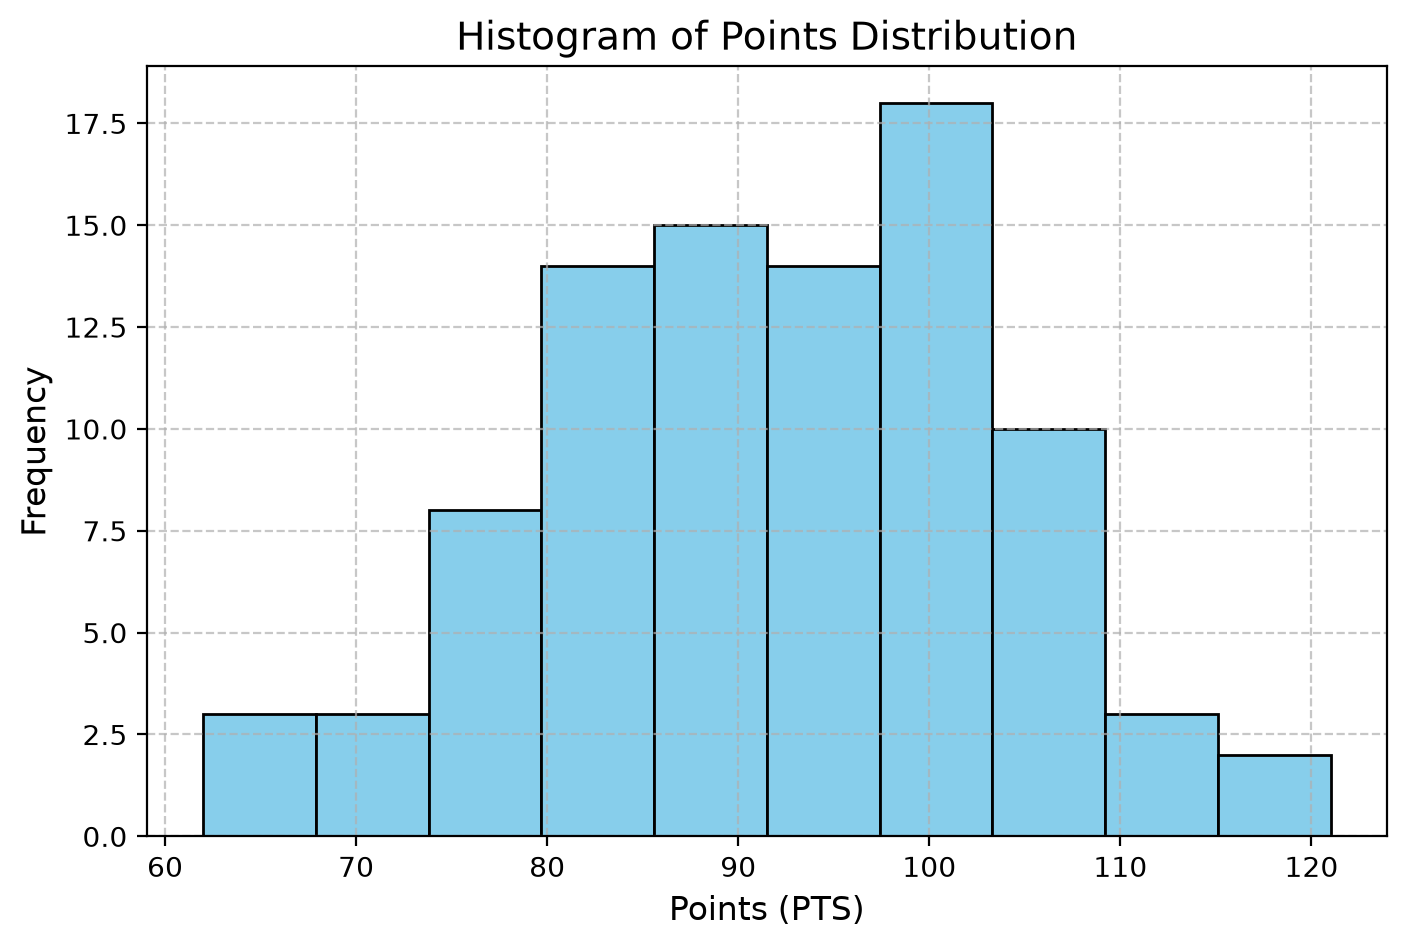

In [25]:
# Create an empty list to store test accuracies
test_accuracies = []

# Try K values from 1 to 20 for simplicity
k_range = range(1, 21)

for k in k_range:
    knn_loop = KNeighborsClassifier(n_neighbors=k)
    knn_loop.fit(X_train, y_train)
    acc = knn_loop.score(X_test, y_test)
    test_accuracies.append(acc)

# Create a histogram for a specific feature (e.g., Points)
plt.figure(figsize=(8, 5))
plt.hist(X['PTS'], bins=10, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Points (PTS)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Points Distribution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 11. Fit KNN across different values of K and plot the mean cross-validated accuracy with 5 folds.

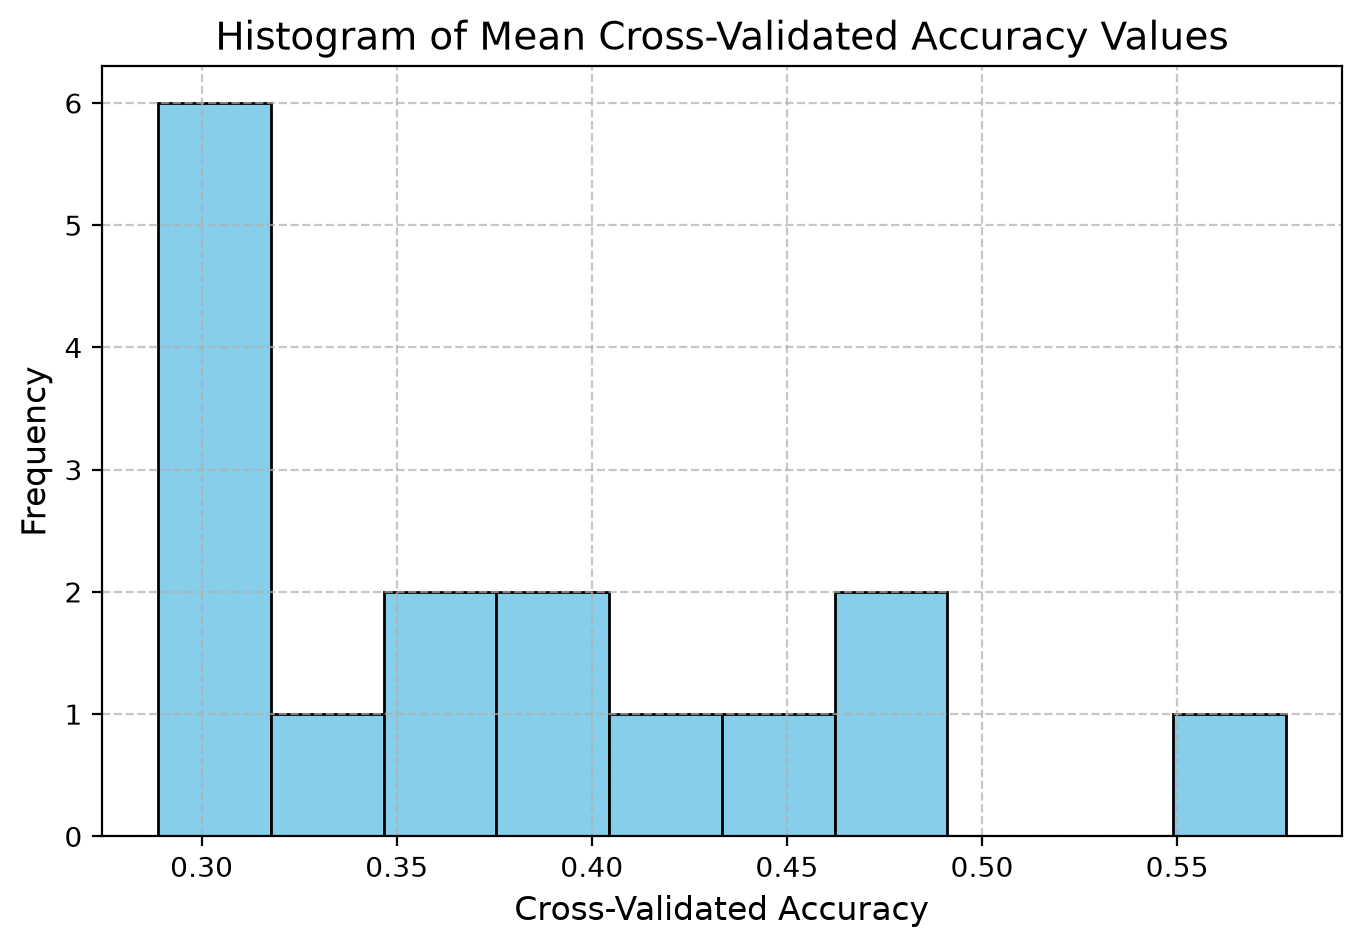

In [28]:
# Perform 5-fold cross-validation for different values of K and plot the histogram
from sklearn.model_selection import cross_val_score

cv_scores = []
k_range = range(1, 32, 2)

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.hist(cv_scores, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Cross-Validated Accuracy', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Mean Cross-Validated Accuracy Values', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 12. Standardize the predictor matrix and cross-validate across the different K.
- Plot the standardized mean cross-validated accuracy against the unstandardized. Which is better?
- Why?

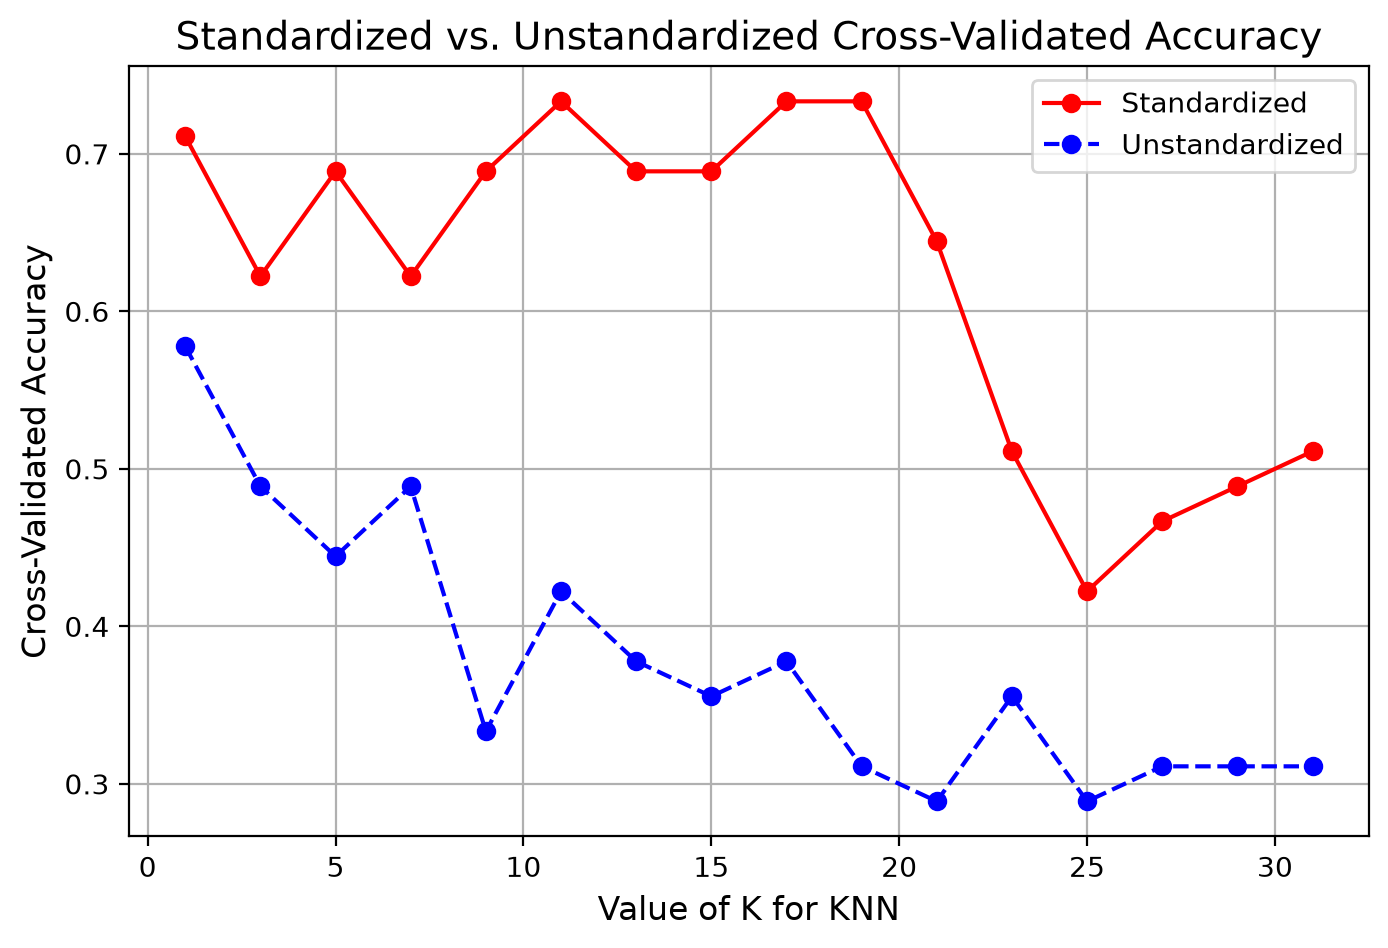

In [31]:
# Standardize the predictor matrix and cross-validate across different values of K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# 1. Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Perform cross-validation with scaled data
cv_scores_scaled = []
k_range = range(1, 32, 2)

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_scaled.append(scores.mean())

# 3. Plot both standardized and unstandardized results to compare
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores_scaled, marker='o', color='r', label='Standardized')
plt.plot(k_range, cv_scores, marker='o', color='b', linestyle='--', label='Unstandardized')

plt.xlabel('Value of K for KNN', fontsize=12)
plt.ylabel('Cross-Validated Accuracy', fontsize=12)
plt.title('Standardized vs. Unstandardized Cross-Validated Accuracy', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

## What was the best 'k'?

Using `GridSearch` & `Pipeline` find the best `k` for the KNN model

In [32]:
# Find the best k value using a pipeline and grid search
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {'knn__n_neighbors': range(1, 32, 2)}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best k:", grid_search.best_params_['knn__n_neighbors'])
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best k: 1
Best Cross-Validation Accuracy: 0.711111111111111
